## Load Data and Split

In [1]:
import os, sys

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import random
from pathlib import Path
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from torchvision import datasets
from torch.utils.data import DataLoader

In [2]:
project_root = "/Users/cindychen/Desktop/EE562/EE562 Assignments/EE562-Classifiers"
if project_root not in sys.path:
    sys.path.append(project_root)

In [3]:
from src.datasets.doggie_loader import get_doggie_dataset, create_doggie_dataloaders, get_default_transforms

## ResNet-18 CNN

Importing all the functions from the resnet file

In [4]:
# importing the functions from the resnet module
from src.models.resnet_cnn import (
    create_resnet18,
    get_default_transforms,
    train_epoch,
    validate_epoch,
    predict_image,
    get_all_predictions
)

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)


In [5]:
#Load dataset

train_dataset, val_dataset, test_dataset, class_names, num_classes = get_doggie_dataset()

train_loader, val_loader, test_loader = create_doggie_dataloaders(
    train_dataset, 
    val_dataset, 
    test_dataset, 
    batch_size=16, 
    num_workers=0
)

print(f"Number of classes: {num_classes}")
print(f"Class names: {class_names[:5]}...")

Number of classes: 120
Train samples: 16418
Val samples: 2009
Test samples: 2153

Using batch size: 16
Train batches: 1027
Validation batches: 126
Test batches: 135
Number of classes: 120
Class names: ['n02085620-Chihuahua', 'n02085782-Japanese_spaniel', 'n02085936-Maltese_dog', 'n02086079-Pekinese', 'n02086240-Shih-Tzu']...


In [6]:
# start the model
model = create_resnet18(num_classes=num_classes)

# model parameter count
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters: {total_params:,}")
print(f"trainable parameters: {trainable_params:,}")


Total parameters: 11,500,728
trainable parameters: 11,500,728


In [7]:
#  Training setup
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.1, patience=3
)

print(f"Loss function: CrossEntropyLoss")
print(f"Optimizer: Adam (lr=0.001, weight_decay=1e-4)")
print(f"Scheduler: ReduceLROnPlateau")

Loss function: CrossEntropyLoss
Optimizer: Adam (lr=0.001, weight_decay=1e-4)
Scheduler: ReduceLROnPlateau


In [8]:
# Training loop
num_epochs = 30
best_val_acc = 0.0

# Lists to store metrics
train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print("-" * 30)
    
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    
    val_loss, val_acc = validate_epoch(model, val_loader, criterion)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    
    scheduler.step(val_loss)
    
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_dog_model.pth')
        print(f"✓ Saved best model (val_acc: {val_acc:.2f}%)")


Epoch 1/30
------------------------------


Training:   0%|          | 0/1027 [00:00<?, ?it/s]

Training:   1%|          | 6/1027 [00:10<29:23,  1.73s/it, Loss=4.7302, Acc=3.12%]


KeyboardInterrupt: 

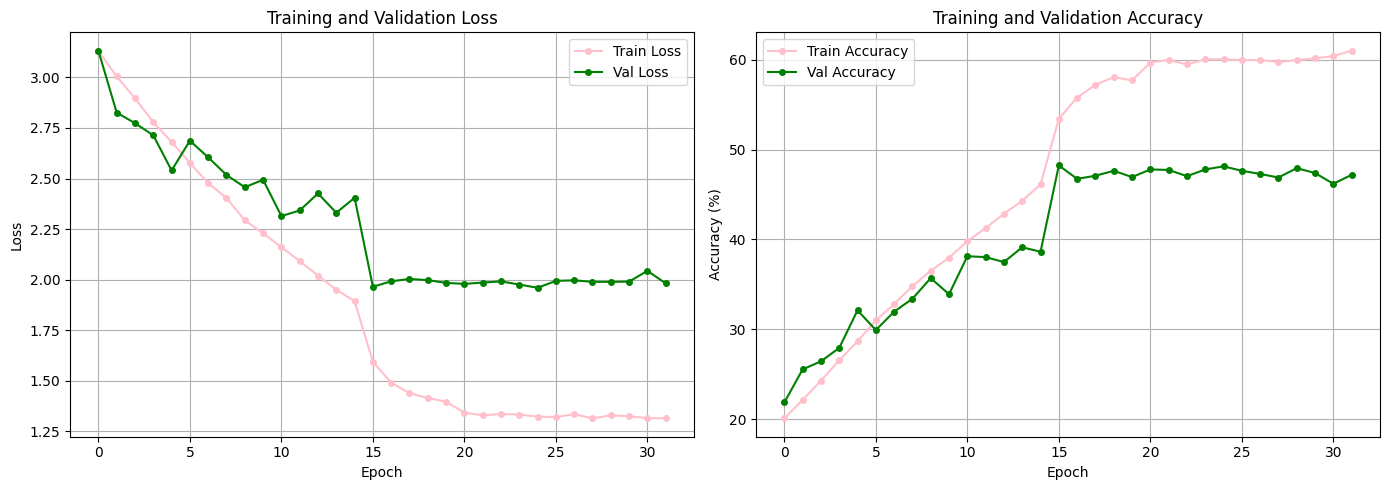

In [ ]:
#plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# plot 1: loss
ax1.plot(train_losses, 'o-', color='pink', label='Train Loss', markersize=4, markerfacecolor='pink', markeredgecolor='pink')
ax1.plot(val_losses, 'o-', color='green', label='Val Loss', markersize=4, markerfacecolor='green', markeredgecolor='green')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()
ax1.grid(True)

# plot 2 accuracy
ax2.plot(train_accs, 'o-', color='pink', label='Train Accuracy', markersize=4, markerfacecolor='pink', markeredgecolor='pink')
ax2.plot(val_accs, 'o-', color='green', label='Val Accuracy', markersize=4, markerfacecolor='green', markeredgecolor='green')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training and Validation Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150)
plt.show()

In [ ]:
#test evaluation

model.load_state_dict(torch.load('best_dog_model.pth'))
test_loss, test_acc = validate_epoch(model, test_loader, criterion)
print(f"\nFinal Test Results:")
print(f"  Test Loss: {test_loss:.4f}")
print(f"  Test Accuracy: {test_acc:.2f}%")

TEST SET EVALUATION


Validation: 100%|██████████| 135/135 [01:16<00:00,  1.76it/s, Loss=1.5660, Acc=45.89%]


Final Test Results:
  Test Loss: 1.9723
  Test Accuracy: 45.89%


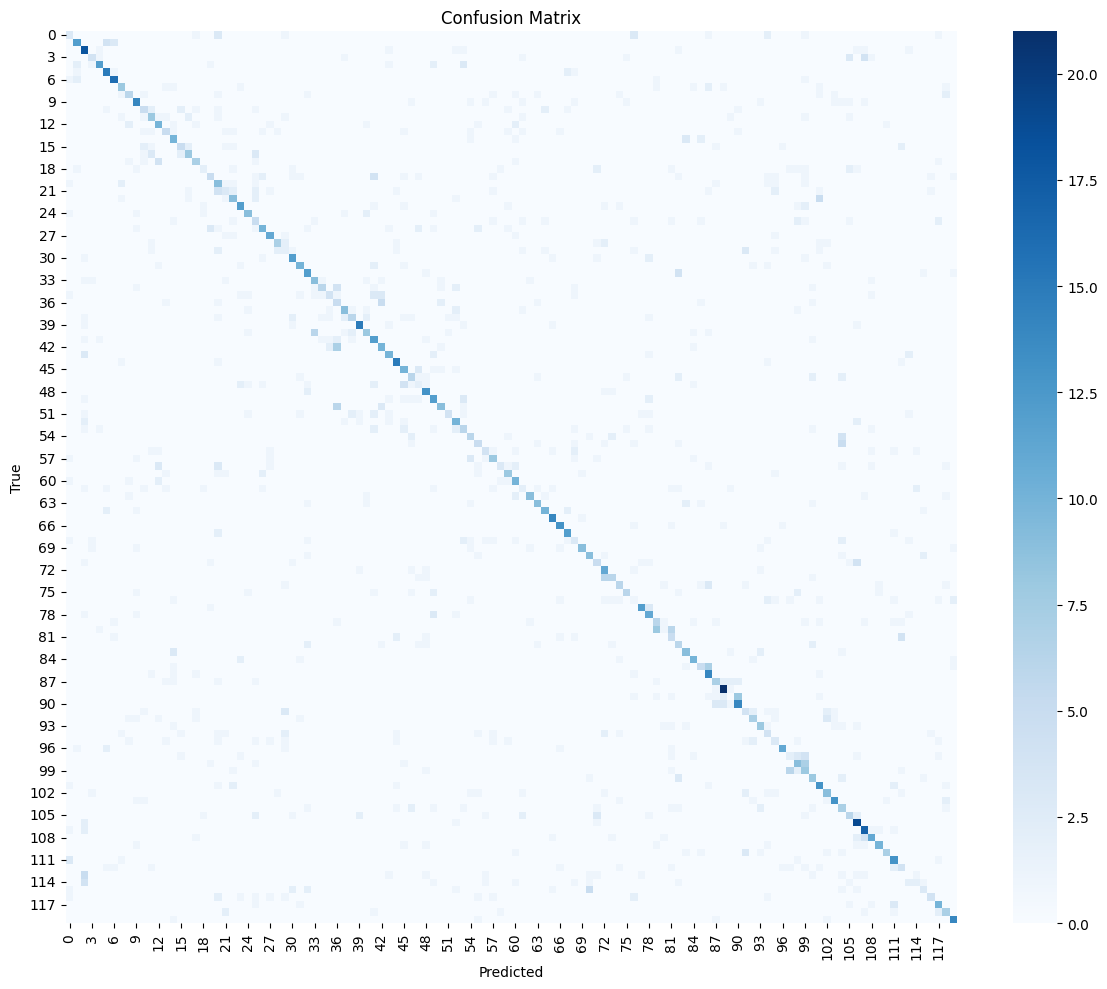

Mean class accuracy: 0.4515


In [ ]:
#confusion matrix
test_preds, test_labels = get_all_predictions(model, test_loader)
cm = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=False, cmap='Blues', cbar=True)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

class_acc = cm.diagonal() / cm.sum(axis=1)
print(f"Mean class accuracy: {np.nanmean(class_acc):.4f}")

In [ ]:
#prediction of a single image
test_idx = random.randint(0, len(test_dataset) - 1)
img_path, true_label = test_dataset.samples[test_idx]
true_breed = class_names[true_label]

pred_breed, confidence = predict_image(img_path, model, class_names, val_transform)
clean_true = ' '.join(true_breed.split('-')[1].split('_')) if '-' in true_breed else true_breed
clean_pred = ' '.join(pred_breed.split('-')[1].split('_')) if '-' in pred_breed else pred_breed

print(f"True breed: {clean_true}")
print(f"Predicted: {clean_pred}")
print(f"Confidence: {confidence:.4f} ({confidence*100:.2f}%)")

True breed: vizsla
Predicted: vizsla
Confidence: 0.3057 (30.57%)
